# Modules

In [2]:
from LC_utility import *

# Read in Data

In [4]:
### historical LC
eta_historic = pdastrostatsclass()
eta_historic.load('LC_tables/data/eta_full_revisedLC.txt', header=None, namesMapping={0:'Author',1:'Year',2:'Mag',3:'Mag_err'})

lc_flux_counts = 10 ** (-0.4 * (eta_historic.t['Mag']))
lc_flux_err = 0.921 * lc_flux_counts * eta_historic.t['Mag_err']
lc_mjd = Time(eta_historic.t['Year'].values, format='decimalyear', scale='utc').mjd + 57339 + 5068

eta_historic.t['Flux'] = lc_flux_counts
eta_historic.t['Flux_err'] = lc_flux_err
eta_historic.t['MJD'] = lc_mjd

/Users/rangulo/programs/anaconda3/lib/python3.11/site-packages/erfa/core.py:154: ErfaWarning: ERFA function "dtf2d" yielded 520 of "dubious year (Note 6)"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),
/Users/rangulo/programs/anaconda3/lib/python3.11/site-packages/erfa/core.py:154: ErfaWarning: ERFA function "utctai" yielded 520 of "dubious year (Note 3)"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),
/Users/rangulo/programs/anaconda3/lib/python3.11/site-packages/erfa/core.py:154: ErfaWarning: ERFA function "taiutc" yielded 520 of "dubious year (Note 4)"
  warnings.warn('ERFA function "{}" yielded {}'.format(func_name, wmsg),


In [5]:
### Read in Models
LCm2_g = pd.read_csv('LC_tables/models/gLC_m2.csv')
LCm2_r = pd.read_csv('LC_tables/models/rLC_m2.csv')
LCm2_i = pd.read_csv('LC_tables/models/iLC_m2.csv')
LCm2_z = pd.read_csv('LC_tables/models/zLC_m2.csv')

In [6]:
### Read in LC data
LCdat_g = pd.read_csv('LC_tables/models/gLC_data2.csv')
LCdat_r = pd.read_csv('LC_tables/models/rLC_data2.csv')
LCdat_i = pd.read_csv('LC_tables/models/iLC_data2.csv')
LCdat_z = pd.read_csv('LC_tables/models/zLC_data2.csv')

In [7]:

# 30.14
# 10.05

1865.1-1834.95
# 1834.95, 1865.1

30.149999999999864

# Plots of LCs

In [9]:
### Read in LC data

# LCtab_g1 = pd.read_csv('LC_tables/data/LCtable1_g.csv')
# LCtab_g2 = pd.read_csv('LC_tables/data/LCtable2_g.csv')
# LCtab_g3 = pd.read_csv('LC_tables/data/LCtable3_g.csv')
# LCtab_g4 = pd.read_csv('LC_tables/data/LCtable4_g.csv')

# LCtab_r1 = pd.read_csv('LC_tables/data/LCtable1_r.csv')
# LCtab_r2 = pd.read_csv('LC_tables/data/LCtable2_r.csv')
# LCtab_r3 = pd.read_csv('LC_tables/data/LCtable3_r.csv')
# LCtab_r4 = pd.read_csv('LC_tables/data/LCtable4_r.csv')

# LCtab_i1 = pd.read_csv('LC_tables/data/LCtable1_i.csv')
# LCtab_i2 = pd.read_csv('LC_tables/data/LCtable2_i.csv')
# LCtab_i3 = pd.read_csv('LC_tables/data/LCtable3_i.csv')
# LCtab_i4 = pd.read_csv('LC_tables/data/LCtable4_i.csv')

# LCtab_z1 = pd.read_csv('LC_tables/data/LCtable1_z.csv')
# LCtab_z2 = pd.read_csv('LC_tables/data/LCtable2_z.csv')
# LCtab_z3 = pd.read_csv('LC_tables/data/LCtable3_z.csv')
# LCtab_z4 = pd.read_csv('LC_tables/data/LCtable4_z.csv')

In [10]:
### Define uncertainty/error cuts

# ## segment 1
# n_sigs1 = [3.0, 1.0]                  # n-sigma cuts based on micro-Jyas2 and its error
# mJyas2_lms1 = None                    # upperlimits on micro-Jyas2 and its error

# ## segment 2
# n_sigs2 = None
# mJyas2_lms2 = [20.0, 1.0]

# ## segment 3
# n_sigs3 = None
# mJyas2_lms3 = [5.0, 1.0]

# ## segment 4
# n_sigs4 = None
# mJyas2_lms4 = [5.0, 1.0]

In [11]:
# ### Fit parmeters of filter i LC

# iparms1 = pd.read_csv('LC_tables/fit_params/f2params_i1.csv').values
# iparms2 = pd.read_csv('LC_tables/fit_params/f2params_i2.csv').values
# iparms3 = pd.read_csv('LC_tables/fit_params/f2params_i3.csv').values
# iparms4 = pd.read_csv('LC_tables/fit_params/f2params_i4.csv').values

In [12]:
# ### See individual segments

# fig, axs = plt.subplots(4,1, dpi = 100, figsize = [8,10], sharex=True)

# axs = axs.flatten()
# axs[3].set_xlabel('MJD (days)', fontsize = 18)

# inds_sig1 = get_LCinds(LCtab_i1, lc_ID=2, n_sigmas=n_sigs1, mJyas2_lms=mJyas2_lms1)
# lc1_t = LCtab_i1['mjd'][inds_sig1]
# lc1_f = LCtab_i1['mJyas2'][inds_sig1]
# lc1_e = LCtab_i1['mJyas2_err'][inds_sig1]
# axs[0].errorbar(lc1_t, lc1_f, yerr=lc1_e, fmt='--o', ecolor='black', color='deepskyblue', label='Loc 1')

# inds_sig2 = get_LCinds(LCtab_i2, lc_ID=34, n_sigmas=n_sigs2, mJyas2_lms=mJyas2_lms2)#, bad_expnums=bad_expnums_a54i)
# lc2_t = LCtab_i2['mjd'][inds_sig2]
# lc2_f = LCtab_i2['mJyas2'][inds_sig2]
# lc2_e = LCtab_i2['mJyas2_err'][inds_sig2]
# axs[1].errorbar(lc2_t, lc2_f, yerr=lc2_e, fmt='--o', ecolor='black', color='mediumseagreen', label='Loc 2')

# inds_sig3 = get_LCinds(LCtab_i3, lc_ID=90, n_sigmas=n_sigs3, mJyas2_lms=mJyas2_lms3)#, bad_expnums=bad_expnums_a54i)
# lc3_t = LCtab_i3['mjd'][inds_sig3]
# lc3_f = LCtab_i3['mJyas2'][inds_sig3]
# lc3_e = LCtab_i3['mJyas2_err'][inds_sig3]
# axs[2].errorbar(lc3_t, lc3_f, yerr=lc3_e, fmt='--o', ecolor='black', color='red', label='Loc 3')

# inds_sig4 = get_LCinds(LCtab_i4, lc_ID=0, n_sigmas=n_sigs4, mJyas2_lms=mJyas2_lms4)#, bad_expnums=bad_expnums_a54i)
# lc4_t = LCtab_i4['mjd'][inds_sig4]
# lc4_f = LCtab_i4['mJyas2'][inds_sig4]
# lc4_e = LCtab_i4['mJyas2_err'][inds_sig4]
# axs[3].errorbar(lc4_t, lc4_f, yerr=lc4_e, fmt='--o', ecolor='black', color='orange', label='Loc 4')

# for ax in axs:
#     ax.minorticks_on()
#     ax.tick_params(axis='x', labelsize=12)
#     ax.tick_params(axis='y', labelsize=12)
#     ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=8)
#     ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=3)
#     ax.ticklabel_format(axis='both', style='plain')
#     ax.set_ylabel('$\mu$Jy/as$^2$', fontsize = 18)
#     ax.legend(fontsize = 14)

# fig.subplots_adjust(wspace=0, hspace=0)

# # axs[0].set_title('Data in i-band', x=0.48, y=1.05, fontsize = 16)
# axs[3].text(56400, -9, 'All Data in i-band', fontsize=16, color='darkred', bbox=dict(fill=False, edgecolor='dimgrey', boxstyle='square,pad=0.4'))

# # # fig.savefig('../figures/display/EtaCar_Pieces.png', bbox_inches = 'tight', dpi=100)

In [13]:
# ### Connect the segments

# fig, ax = plt.subplots(dpi = 100, figsize = [8,10])
# ax.minorticks_on()
# ax.tick_params(axis='x', labelsize=12)
# ax.tick_params(axis='y', labelsize=12)
# ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
# ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
# ax.set_xlabel('Phase (yrs)', fontsize = 18)
# ax.set_ylabel('$\mu$Jy/as$^2$', fontsize = 18)
# # ax.set_title('Light Curve of filter i', x=0.4, y=0.9, fontsize = 16)
# ax.ticklabel_format(axis='both', style='plain')


# ax.axhline(y=0, linestyle='--', color='black')

# n_offset = 1.

# id1 = np.where(iparms1[0]==2)[0]
# n_lc1_t = lc1_t + iparms1[1][id1]
# n_lc1_phases = n_lc1_t - 57430.
# n_lc1_f = (lc1_f - iparms1[3][id1])/iparms1[2][id1] + n_offset
# n_lc1_e = lc1_e/iparms1[2][id1]
# ax.errorbar(n_lc1_phases/365, n_lc1_f, yerr=n_lc1_e, fmt='--o', ecolor='black', color='deepskyblue', label='Loc 1')

# id2 = np.where(iparms2[0]==34)[0]
# n_lc2_t = lc2_t + iparms2[1][id2]
# n_lc2_phases = n_lc2_t - 57430.
# n_lc2_f = (lc2_f - iparms2[3][id2])/iparms2[2][id2] + n_offset
# n_lc2_e = lc2_e/iparms2[2][id2]
# ax.errorbar(n_lc2_phases/365, n_lc2_f, yerr=n_lc2_e, fmt='--o', ecolor='black', color='mediumseagreen', label='Loc 2')

# id3 = np.where(iparms3[0]==90)[0]
# n_lc3_t = lc3_t + iparms3[1][id3]
# n_lc3_phases = n_lc3_t - 57430.
# n_lc3_f = (lc3_f - iparms3[3][id3])/iparms3[2][id3] + n_offset
# n_lc3_e = lc3_e/iparms3[2][id3]
# ax.errorbar(n_lc3_phases/365, n_lc3_f, yerr=n_lc3_e, fmt='--o', ecolor='black', color='red', label='Loc 3')

# id4 = np.where(iparms4[0]==0)[0]
# n_lc4_t = lc4_t + iparms4[1][id4]
# n_lc4_phases = n_lc4_t - 57430.
# n_lc4_f = (lc4_f - iparms4[3][id4])/iparms4[2][id4] + n_offset
# n_lc4_e = lc4_e/iparms4[2][id4]
# ax.errorbar(n_lc4_phases/365, n_lc4_f, yerr=n_lc4_e, fmt='--o', ecolor='black', color='orange', label='Loc 4')

# ax.legend(fontsize=14)

# ax.text(-10, 62, 'i-band', fontsize=16, color='darkred', bbox=dict(fill=False, edgecolor='dimgrey', boxstyle='square,pad=0.4'))

# # fig.savefig('../figures/display/EtaCar_ConnectPieces.png', bbox_inches = 'tight', dpi=100)

# Plots of the Models

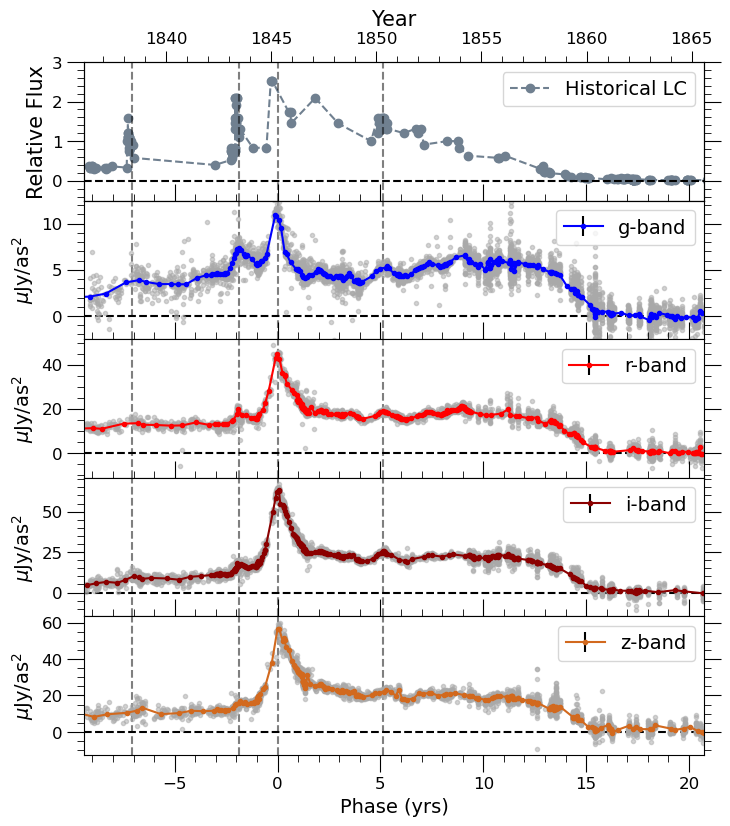

In [15]:
fig, axs = plt.subplots(5,1,dpi = 100, figsize = [8,9], sharex=True)
axs = axs.flatten()

# x_p = [LCm2_g['mjd'], LCm2_r['mjd'], LCm2_i['mjd'], LCm2_z['mjd']]
x_p = [LCm2_g['phase'], LCm2_r['phase'], LCm2_i['phase'], LCm2_z['phase']]

# x_colnm = 'mjd'
x_colnm = 'phase'

# day2yr = 1.
day2yr = 365.

axs[0].errorbar((eta_historic.t['MJD'] - 57430.)/day2yr, eta_historic.t['Flux'], fmt='--o', color='slategray', label='Historical LC', zorder=0)

m_inds_g = np.where(LCdat_g['4model_flag']==True)[0]
m_inds_r = np.where(LCdat_r['4model_flag']==True)[0]
m_inds_i = np.where(LCdat_i['4model_flag']==True)[0]
m_inds_z = np.where(LCdat_z['4model_flag']==True)[0]
axs[1].errorbar(LCdat_g.loc[m_inds_g,x_colnm]/day2yr, LCdat_g.loc[m_inds_g,'mJyas2'], fmt='.', color='darkgray', alpha=0.5)
axs[2].errorbar(LCdat_r.loc[m_inds_r,x_colnm]/day2yr, LCdat_r.loc[m_inds_r,'mJyas2'], fmt='.', color='darkgray', alpha=0.5)
axs[3].errorbar(LCdat_i.loc[m_inds_i,x_colnm]/day2yr, LCdat_i.loc[m_inds_i,'mJyas2'], fmt='.', color='darkgray', alpha=0.5)
axs[4].errorbar(LCdat_z.loc[m_inds_z,x_colnm]/day2yr, LCdat_z.loc[m_inds_z,'mJyas2'], fmt='.', color='darkgray', alpha=0.5)
    
axs[1].errorbar(LCm2_g[x_colnm]/day2yr, LCm2_g['mJyas2'], yerr=LCm2_g['mJyas2_err'], fmt='.-', ecolor='black', color='blue', label='g-band')
axs[2].errorbar(LCm2_r[x_colnm]/day2yr, LCm2_r['mJyas2'], yerr=LCm2_r['mJyas2_err'], fmt='.-', ecolor='black', color='red', label='r-band')
axs[3].errorbar(LCm2_i[x_colnm]/day2yr, LCm2_i['mJyas2'], yerr=LCm2_i['mJyas2_err'], fmt='.-', ecolor='black', color='darkred', label='i-band')
axs[4].errorbar(LCm2_z[x_colnm]/day2yr, LCm2_z['mJyas2'], yerr=LCm2_z['mJyas2_err'], fmt='.-', ecolor='black', color='chocolate', label='z-band')

# axs[4].set_xlabel('MJD (days)', fontsize = 14)
axs[4].set_xlabel('Phase (yrs)', fontsize = 14)
fig.subplots_adjust(wspace=0, hspace=0)
for ax in axs:
    ax.minorticks_on()
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
    ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
    ax.set_ylabel('$\mu$Jy/as$^2$', fontsize = 14)
    ax.ticklabel_format(axis='both', style='plain')

    ax.axhline(y=0, linestyle='--', color='black')
    ax.legend(fontsize = 14)

    # phase_offset = 0.
    phase_offset = -57430.
    ax.set_xlim((54000+phase_offset)/day2yr, (65000+phase_offset)/day2yr)
    ax.axvline((54850+phase_offset)/day2yr, color='k', ls='--', alpha=0.5)
    ax.axvline((56740+phase_offset)/day2yr, color='k', ls='--', alpha=0.5)
    ax.axvline((57430+phase_offset)/day2yr, color='k', ls='--', alpha=0.5)
    ax.axvline((59300+phase_offset)/day2yr, color='k', ls='--', alpha=0.5)

axs[0].set_ylabel('Relative Flux', fontsize = 15)
axs[1].legend(loc=1, fontsize=14)

axs[1].set_ylim(-2.5,12.5)

axs[0].tick_params(which='both', bottom='off', labelbottom='off')
ax_y = axs[0].twiny()
# ax_y.errorbar(eta_historic.t['Year'], eta_historic.t['Flux'], fmt='--o', color='slategray', label='Historical LC')
ax_y.set_xlim(1836.1, 1865.6)
ax_y.set_ylim(-0.5, 3.)
ax_y.set_xlabel('Year', fontsize = 15)
ax_y.minorticks_on()
ax_y.tick_params(axis='x', which='major', labelsize=12, width=0.75)
ax_y.tick_params(which='major', length=8)
ax_y.tick_params(which='minor', length=4)
# ax_y.tick_params(which='major',bottom='off',labelbottom='off',top='on',length=8)
# ax_y.tick_params(which='minor',bottom='off',labelbottom='off',top='on',length=4)

fig.savefig('../figures/display/HistoricalvsLEs.png', bbox_inches = 'tight', dpi = 100)

In [16]:
# Convert from flux to magnitude

working_inds_g = np.where(LCm2_g['mJyas2']>0.)[0]
working_inds_r = np.where(LCm2_r['mJyas2']>0.)[0]
working_inds_i = np.where(LCm2_i['mJyas2']>0.)[0]
working_inds_z = np.where(LCm2_z['mJyas2']>0.)[0]

mag_g, mag_err_g = convert_Jy2mag(LCm2_g.loc[working_inds_g,'mJyas2'].values, err_jy=LCm2_g.loc[working_inds_g,'mJyas2_err'].values)
mag_r, mag_err_r = convert_Jy2mag(LCm2_r.loc[working_inds_r,'mJyas2'].values, err_jy=LCm2_r.loc[working_inds_r,'mJyas2_err'].values)
mag_i, mag_err_i = convert_Jy2mag(LCm2_i.loc[working_inds_i,'mJyas2'].values, err_jy=LCm2_i.loc[working_inds_i,'mJyas2_err'].values)
mag_z, mag_err_z = convert_Jy2mag(LCm2_z.loc[working_inds_z,'mJyas2'].values, err_jy=LCm2_z.loc[working_inds_z,'mJyas2_err'].values)

LCm2_g.loc[working_inds_g,'AB_mag'] = np.array(mag_g)
LCm2_g.loc[working_inds_g,'AB_mag_err'] = np.array(mag_err_g)
LCm2_r.loc[working_inds_r,'AB_mag'] = np.array(mag_r)
LCm2_r.loc[working_inds_r,'AB_mag_err'] = np.array(mag_err_r)
LCm2_i.loc[working_inds_i,'AB_mag'] = np.array(mag_i)
LCm2_i.loc[working_inds_i,'AB_mag_err'] = np.array(mag_err_i)
LCm2_z.loc[working_inds_z,'AB_mag'] = np.array(mag_z)
LCm2_z.loc[working_inds_z,'AB_mag_err'] = np.array(mag_err_z)

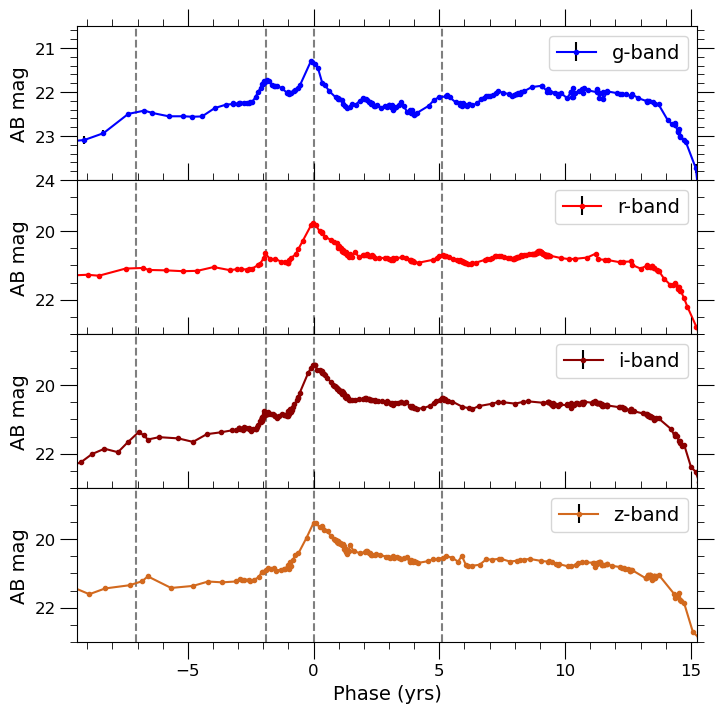

In [17]:
fig, axs = plt.subplots(4,1,dpi = 100, figsize = [8,8], sharex=True)
axs = axs.flatten()
fig.subplots_adjust(wspace=0, hspace=0)

# x_colnm = 'mjd'
x_colnm = 'phase'
# day2yr = 1.
day2yr = 365.

axs[0].errorbar(LCm2_g.loc[working_inds_g,x_colnm]/day2yr, LCm2_g.loc[working_inds_g,'AB_mag'], LCm2_g.loc[working_inds_g,'AB_mag_err'], fmt='.-', ecolor='black', color='blue', label='g-band')
axs[1].errorbar(LCm2_r.loc[working_inds_r,x_colnm]/day2yr, LCm2_r.loc[working_inds_r,'AB_mag'], LCm2_r.loc[working_inds_r,'AB_mag_err'], fmt='.-', ecolor='black', color='red', label='r-band')
axs[2].errorbar(LCm2_i.loc[working_inds_i,x_colnm]/day2yr, LCm2_i.loc[working_inds_i,'AB_mag'], LCm2_i.loc[working_inds_i,'AB_mag_err'], fmt='.-', ecolor='black', color='darkred', label='i-band')
axs[3].errorbar(LCm2_z.loc[working_inds_z,x_colnm]/day2yr, LCm2_z.loc[working_inds_z,'AB_mag'], LCm2_z.loc[working_inds_z,'AB_mag_err'], fmt='.-', ecolor='black', color='chocolate', label='z-band')

# axs[3].set_xlabel('MJD (days)', fontsize = 14)
axs[3].set_xlabel('Phase (yrs)', fontsize = 14)

for ax in axs:
    ax.minorticks_on()
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
    ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
    ax.set_ylabel('AB mag', fontsize = 14)
    ax.ticklabel_format(axis='both', style='plain')

    ax.set_ylim(18.5,23)
    # ax.set_ylim(20.5,23)
    ax.invert_yaxis()
    ax.legend(fontsize = 14)

    # phase_offset = 0.
    phase_offset = -57430.
    ax.set_xlim((54000+phase_offset)/day2yr, (63000+phase_offset)/day2yr)
    # ax.set_xlim((54000+phase_offset+2430)/day2yr, (63000+phase_offset-3570)/day2yr)
    
    ax.axvline((54850+phase_offset)/day2yr, color='k', ls='--', alpha=0.5)
    ax.axvline((56740+phase_offset)/day2yr, color='k', ls='--', alpha=0.5)
    ax.axvline((57430+phase_offset)/day2yr, color='k', ls='--', alpha=0.5)
    ax.axvline((59300+phase_offset)/day2yr, color='k', ls='--', alpha=0.5)

axs[0].set_ylim(24., 20.5)

fig.savefig('../figures/ec0915/griz_EtaCarLCs_mag.png', bbox_inches = 'tight', dpi = 100)

In [18]:
### Create spline for color plots

t_ran = np.arange(54000, 63500)

g_new = splev(t_ran, splrep(LCm2_g.loc[working_inds_g,'mjd'], LCm2_g.loc[working_inds_g,'AB_mag'], k=1))
g_new_u = splev(t_ran, splrep(LCm2_g.loc[working_inds_g,'mjd'], LCm2_g.loc[working_inds_g,'AB_mag']+LCm2_g.loc[working_inds_g,'AB_mag_err'], k=1))
g_new_l = splev(t_ran, splrep(LCm2_g.loc[working_inds_g,'mjd'], LCm2_g.loc[working_inds_g,'AB_mag']-LCm2_g.loc[working_inds_g,'AB_mag_err'], k=1))
                
r_new = splev(t_ran, splrep(LCm2_r.loc[working_inds_r,'mjd'], LCm2_r.loc[working_inds_r,'AB_mag'], k=1, w=1/LCm2_r.loc[working_inds_r,'AB_mag_err']))
r_new_u = splev(t_ran, splrep(LCm2_r.loc[working_inds_r,'mjd'], LCm2_r.loc[working_inds_r,'AB_mag']+LCm2_r.loc[working_inds_r,'AB_mag_err'], k=1))
r_new_l = splev(t_ran, splrep(LCm2_r.loc[working_inds_r,'mjd'], LCm2_r.loc[working_inds_r,'AB_mag']-LCm2_r.loc[working_inds_r,'AB_mag_err'], k=1))

i_new = splev(t_ran, splrep(LCm2_i.loc[working_inds_i,'mjd'], LCm2_i.loc[working_inds_i,'AB_mag'], k=1, w=1/LCm2_i.loc[working_inds_i,'AB_mag_err']))
i_new_u = splev(t_ran, splrep(LCm2_i.loc[working_inds_i,'mjd'], LCm2_i.loc[working_inds_i,'AB_mag']+LCm2_i.loc[working_inds_i,'AB_mag_err'], k=1))
i_new_l = splev(t_ran, splrep(LCm2_i.loc[working_inds_i,'mjd'], LCm2_i.loc[working_inds_i,'AB_mag']-LCm2_i.loc[working_inds_i,'AB_mag_err'], k=1))

z_new = splev(t_ran, splrep(LCm2_z.loc[working_inds_z,'mjd'], LCm2_z.loc[working_inds_z,'AB_mag'], k=1, w=1/LCm2_z.loc[working_inds_z,'AB_mag_err']))
z_new_u = splev(t_ran, splrep(LCm2_z.loc[working_inds_z,'mjd'], LCm2_z.loc[working_inds_z,'AB_mag']+LCm2_z.loc[working_inds_z,'AB_mag_err'], k=1))
z_new_l = splev(t_ran, splrep(LCm2_z.loc[working_inds_z,'mjd'], LCm2_z.loc[working_inds_z,'AB_mag']-LCm2_z.loc[working_inds_z,'AB_mag_err'], k=1))

In [19]:
### checking how error looks

# plt.subplots(dpi = 100, figsize = [12,6])
# plt.minorticks_on()
# plt.tick_params(axis='x', labelsize=12)
# plt.tick_params(axis='y', labelsize=12)
# plt.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
# plt.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
# plt.gca().set_xlabel('mjd', fontsize = 14)
# plt.gca().set_ylabel('AB mag', fontsize = 14)
# plt.ticklabel_format(axis='both', style='plain')


# plt.errorbar(t_ran, g_new, ecolor='black', color='blue', label='g band')
# plt.errorbar(t_ran, g_new_u, ecolor='black', color='cyan', label='g band - u', alpha=0.5)
# plt.errorbar(t_ran, g_new_l, ecolor='black', color='green', label='g band - l', alpha=0.5)

# # plt.errorbar(t_ran, r_new, ecolor='black', color='red', label='r band')
# # plt.errorbar(t_ran, i_new, ecolor='black', color='darkred', label='i band')
# # plt.errorbar(t_ran, z_new, ecolor='black', color='chocolate', label='z band')

# plt.ylim(19,24)
# plt.gca().invert_yaxis()
# plt.legend()

# # plt.axvline(54850, color='k', ls='--')
# # plt.axvline(56740, color='k', ls='--')
# # plt.axvline(57430, color='k', ls='--')
# # plt.axvline(59300, color='k', ls='--')

# Comparing Plots

In [21]:
# fig, axs = plt.subplots(3,1,dpi = 100, figsize = [8,8], sharex=True)
# axs = axs.flatten()

# # day_or_yr = 1.
# day_or_yr = 365.

# axs[0].errorbar((eta_historic.t['MJD'] - 57430.)/day_or_yr, eta_historic.t['Flux'], fmt='--o', color='slategray', label='Historical LC', zorder=0)
# axs[1].errorbar((LCdat_g.loc[m_inds_g,'mjd'] - 57430.)/day_or_yr, LCdat_g.loc[m_inds_g,'mJyas2'], fmt='.', color='skyblue', alpha=0.5)
# axs[1].errorbar((LCm2_g['mjd'] - 57430.)/day_or_yr, LCm2_g['mJyas2'], fmt='-', color='blue',label='Light Echo LC')
# axs[2].errorbar((LCdat_i.loc[m_inds_i,'mjd'] - 57430.)/day_or_yr, LCdat_i.loc[m_inds_i,'mJyas2'], fmt='.', color='lightsalmon', alpha=0.5)
# axs[2].errorbar((LCm2_i['mjd'] - 57430.)/day_or_yr, LCm2_i['mJyas2'], fmt='-', color='darkred',label='Light Echo LC')

# axs[0].set_ylabel('Relative Flux', fontsize = 15)
# axs[1].set_ylabel('$\mu$Jy/as$^2$', fontsize = 15)
# axs[2].set_ylabel('$\mu$Jy/as$^2$', fontsize = 15)
# # axs[2].set_xlabel('Phase (days)', fontsize = 15)
# axs[2].set_xlabel('Phase (yrs)', fontsize = 15)

# axs[1].set_ylim(-2., 12)
# axs[2].set_ylim(-10., 70)

# axs[0].legend(fontsize = 14)
# axs[1].legend(fontsize = 14)
# axs[2].legend(fontsize = 14)

# axs[1].text((54300 - 57430.)/day_or_yr, 9.5, 'g-band', fontsize=16, color='blue', bbox=dict(fill=True, facecolor='white', edgecolor='white', boxstyle='square,pad=0.1'),zorder=6)
# axs[2].text((54400 - 57430.)/day_or_yr, 56, 'i-band', fontsize=16, color='darkred', bbox=dict(fill=True, facecolor='white', edgecolor='white', boxstyle='square,pad=0.1'),zorder=6)

# for ax in axs:
#     ax.minorticks_on()
#     ax.tick_params(axis='both', which='both', labelsize=12, width=0.75)
#     ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=8)
#     ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=4)
#     ax.ticklabel_format(axis='both', style='plain')

#     ax.set_xlim((54000 - 57430.)/day_or_yr, (64000 - 57430.)/day_or_yr)
#     ax.axvline((54850 - 57430.)/day_or_yr, color='red', ls='--', alpha=0.75, zorder=5, lw=2.)
#     ax.axvline((56740 - 57430.)/day_or_yr, color='red', ls='--', alpha=0.75, zorder=5, lw=2.)
#     ax.axvline((57430 - 57430.)/day_or_yr, color='red', ls='--', alpha=0.75, zorder=5, lw=2.)
#     ax.axvline((59300 - 57430.)/day_or_yr, color='red', ls='--', alpha=0.75, zorder=5, lw=2.)

#     ax.axhline(y=0, linestyle='--', color='grey')

# # axs[2].tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
# # axs[2].tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
# # axs[2].ticklabel_format(axis='both', style='plain')

# axs[0].tick_params(which='both', bottom='off', labelbottom='off')
# ax_y = axs[0].twiny()
# ax_y.errorbar(eta_historic.t['Year'], eta_historic.t['Flux'], fmt='--o', color='slategray', label='Historical LC')
# ax_y.set_xlim(1835.86, 1863.24)
# ax_y.set_xlabel('Year', fontsize = 15)
# ax_y.minorticks_on()
# ax_y.tick_params(axis='x', which='major', labelsize=12, width=0.75)
# ax_y.tick_params(which='major', length=8)
# ax_y.tick_params(which='minor', length=4)
# # ax_y.tick_params(which='major',bottom='off',labelbottom='off',top='on',length=8)
# # ax_y.tick_params(which='minor',bottom='off',labelbottom='off',top='on',length=4)

# fig.subplots_adjust(wspace=0, hspace=0)

# # fig.savefig('../figures/display/HistoricalvsLEs.png', bbox_inches = 'tight', dpi = 100)

# Color Plots

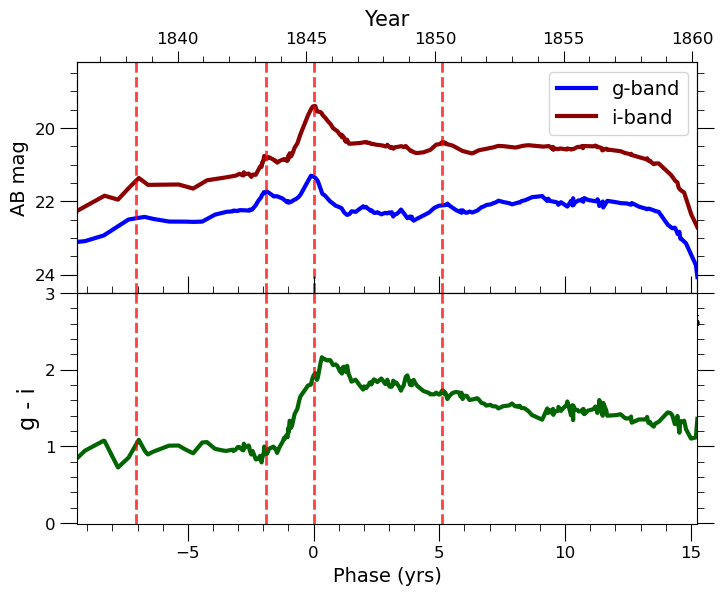

In [23]:
# g - i

y1 = g_new
y2 = i_new

fig, axs = plt.subplots(2,1,dpi = 100, figsize = [8,6], sharex=True)
axs = axs.flatten()

# day2yr = 1.
day2yr = 365.

# phase_offset = 0.
phase_offset = -57430.

axs[0].errorbar((t_ran+phase_offset)/day2yr, y1, ecolor='black', color='blue',label='g-band',linewidth=3)
axs[0].errorbar((t_ran+phase_offset)/day2yr, y2, ecolor='black', color='darkred',label='i-band', linewidth=3)
axs[0].set_ylabel('AB mag', fontsize = 14)
axs[0].set_ylim(18.2, 24.5)
axs[0].invert_yaxis()
axs[0].legend(fontsize = 14)

axs[1].errorbar((t_ran+phase_offset)/day2yr, y1-y2, ecolor='black', color='darkgreen', linewidth=3)
axs[1].set_xlabel('Phase (yrs)', fontsize = 14)
axs[1].set_ylabel('g - i', fontsize = 16)
axs[1].set_ylim(-0.01,3.0)

for ax in axs:
    ax.minorticks_on()
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
    ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
    ax.ticklabel_format(axis='both', style='plain')
    
    ax.set_xlim((54000+phase_offset)/day2yr, (63000+phase_offset)/day2yr)
    ax.axvline((54850+phase_offset)/day2yr, color='red', ls='--', alpha=0.75, zorder=5, lw=2.)
    ax.axvline((56740+phase_offset)/day2yr, color='red', ls='--', alpha=0.75, zorder=5, lw=2.)
    ax.axvline((57430+phase_offset)/day2yr, color='red', ls='--', alpha=0.75, zorder=5, lw=2.)
    ax.axvline((59300+phase_offset)/day2yr, color='red', ls='--', alpha=0.75, zorder=5, lw=2.)

fig.subplots_adjust(wspace=0, hspace=0)

axs[0].tick_params(which='both', bottom='off', labelbottom='off')
ax_y = axs[0].twiny()
ax_y.errorbar(eta_historic.t['Year'], eta_historic.t['Flux'], fmt='--o', color='slategray', label='Historical LC')
# ax_y.set_xlim(1835.86, 1860.5)
ax_y.set_xlim(1836.1, 1860.2)
ax_y.set_xlabel('Year', fontsize = 15)
ax_y.minorticks_on()
ax_y.tick_params(axis='x', which='major', labelsize=12, width=0.75)
ax_y.tick_params(which='major', length=8)
ax_y.tick_params(which='minor', length=4)

fig.savefig('../figures/display/g-i_Color.png', bbox_inches = 'tight', dpi = 100)

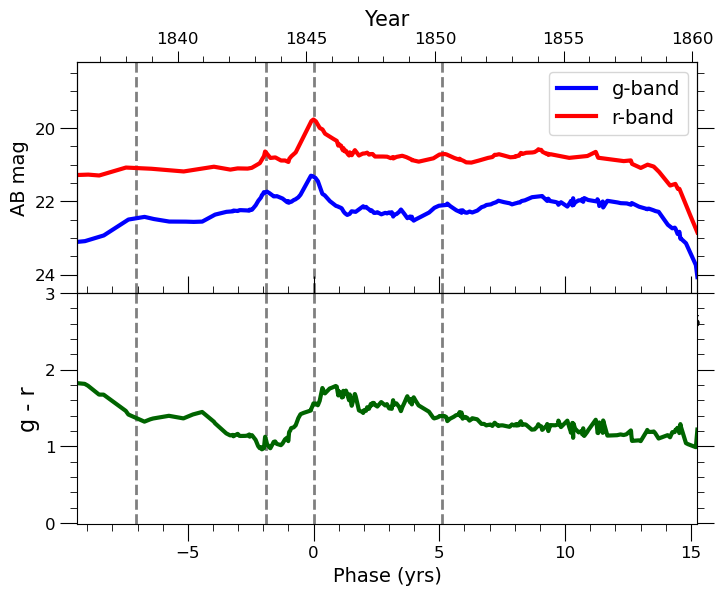

In [24]:
# g - r

y1 = g_new
y2 = r_new

fig, axs = plt.subplots(2,1,dpi = 100, figsize = [8,6], sharex=True)
axs = axs.flatten()

# day2yr = 1.
day2yr = 365.

# phase_offset = 0.
phase_offset = -57430.

axs[0].errorbar((t_ran+phase_offset)/day2yr, y1, ecolor='black', color='blue',label='g-band', linewidth=3)
axs[0].errorbar((t_ran+phase_offset)/day2yr, y2, ecolor='black', color='red',label='r-band', linewidth=3)
axs[0].set_ylabel('AB mag', fontsize = 14)
axs[0].set_ylim(18.2, 24.5)
axs[0].invert_yaxis()
axs[0].legend(fontsize = 14)

axs[1].errorbar((t_ran+phase_offset)/day2yr, y1-y2, ecolor='black', color='darkgreen', linewidth=3)
# axs[1].set_xlabel('MJD (days)', fontsize = 14)
axs[1].set_xlabel('Phase (yrs)', fontsize = 14)
axs[1].set_ylabel('g - r', fontsize = 16)
axs[1].set_ylim(-0.01,3.0)

for ax in axs:
    ax.minorticks_on()
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
    ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
    ax.ticklabel_format(axis='both', style='plain')

    ax.set_xlim((54000+phase_offset)/day2yr, (63000+phase_offset)/day2yr)
    ax.axvline((54850+phase_offset)/day2yr, color='k', ls='--', alpha=0.5, lw=2)
    ax.axvline((56740+phase_offset)/day2yr, color='k', ls='--', alpha=0.5, lw=2)
    ax.axvline((57430+phase_offset)/day2yr, color='k', ls='--', alpha=0.5, lw=2)
    ax.axvline((59300+phase_offset)/day2yr, color='k', ls='--', alpha=0.5, lw=2)

fig.subplots_adjust(wspace=0, hspace=0)

axs[0].tick_params(which='both', bottom='off', labelbottom='off')
ax_y = axs[0].twiny()
ax_y.errorbar(eta_historic.t['Year'], eta_historic.t['Flux'], fmt='--o', color='slategray', label='Historical LC')
# ax_y.set_xlim(1835.86, 1860.5)
ax_y.set_xlim(1836.1, 1860.2)
ax_y.set_xlabel('Year', fontsize = 15)
ax_y.minorticks_on()
ax_y.tick_params(axis='x', which='major', labelsize=12, width=0.75)
ax_y.tick_params(which='major', length=8)
ax_y.tick_params(which='minor', length=4)

fig.savefig('../figures/display/g-r_Color.png', bbox_inches = 'tight', dpi = 100)

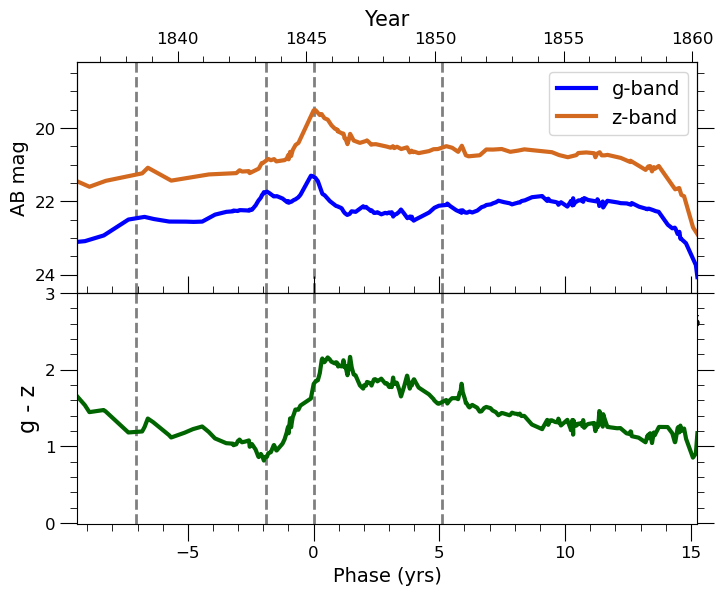

In [25]:
# g - z

y1 = g_new
y2 = z_new

fig, axs = plt.subplots(2,1,dpi = 100, figsize = [8,6], sharex=True)
axs = axs.flatten()

# day2yr = 1.
day2yr = 365.

# phase_offset = 0.
phase_offset = -57430.

axs[0].errorbar((t_ran+phase_offset)/day2yr, y1, ecolor='black', color='blue',label='g-band', linewidth=3)
axs[0].errorbar((t_ran+phase_offset)/day2yr, y2, ecolor='black', color='chocolate',label='z-band', linewidth=3)
axs[0].set_ylabel('AB mag', fontsize = 14)
axs[0].set_ylim(18.2, 24.5)
axs[0].invert_yaxis()
axs[0].legend(fontsize = 14)

axs[1].errorbar((t_ran+phase_offset)/day2yr, y1-y2, ecolor='black', color='darkgreen', linewidth=3)
# axs[1].set_xlabel('MJD (days)', fontsize = 14)
axs[1].set_xlabel('Phase (yrs)', fontsize = 14)
axs[1].set_ylabel('g - z', fontsize = 16)
axs[1].set_ylim(-0.01,3.0)

for ax in axs:
    ax.minorticks_on()
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
    ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
    ax.ticklabel_format(axis='both', style='plain')

    ax.set_xlim((54000+phase_offset)/day2yr, (63000+phase_offset)/day2yr)
    ax.axvline((54850+phase_offset)/day2yr, color='k', ls='--', alpha=0.5, lw=2)
    ax.axvline((56740+phase_offset)/day2yr, color='k', ls='--', alpha=0.5, lw=2)
    ax.axvline((57430+phase_offset)/day2yr, color='k', ls='--', alpha=0.5, lw=2)
    ax.axvline((59300+phase_offset)/day2yr, color='k', ls='--', alpha=0.5, lw=2)

fig.subplots_adjust(wspace=0, hspace=0)

axs[0].tick_params(which='both', bottom='off', labelbottom='off')
ax_y = axs[0].twiny()
ax_y.errorbar(eta_historic.t['Year'], eta_historic.t['Flux'], fmt='--o', color='slategray', label='Historical LC')
# ax_y.set_xlim(1835.86, 1860.5)
ax_y.set_xlim(1836.1, 1860.2)
ax_y.set_xlabel('Year', fontsize = 15)
ax_y.minorticks_on()
ax_y.tick_params(axis='x', which='major', labelsize=12, width=0.75)
ax_y.tick_params(which='major', length=8)
ax_y.tick_params(which='minor', length=4)

fig.savefig('../figures/display/g-z_Color.png', bbox_inches = 'tight', dpi = 100)

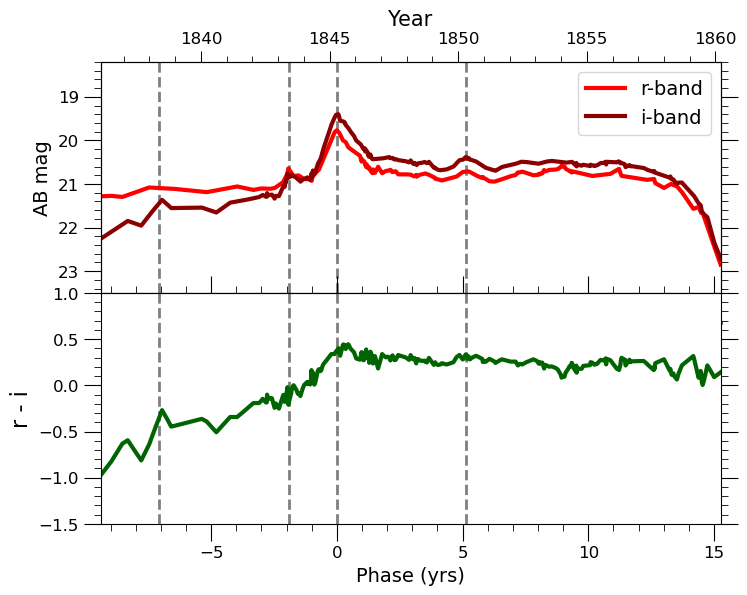

In [26]:
# r - i

y1 = r_new
y2 = i_new

fig, axs = plt.subplots(2,1,dpi = 100, figsize = [8,6], sharex=True)
axs = axs.flatten()

axs[0].errorbar((t_ran+phase_offset)/day2yr, y1, ecolor='black', color='red',label='r-band', linewidth=3)
axs[0].errorbar((t_ran+phase_offset)/day2yr, y2, ecolor='black', color='darkred',label='i-band', linewidth=3)
axs[0].set_ylabel('AB mag', fontsize = 14)
axs[0].set_ylim(18.2, 23.5)
axs[0].invert_yaxis()
axs[0].legend(fontsize = 14)

axs[1].errorbar((t_ran+phase_offset)/day2yr, y1-y2, ecolor='black', color='darkgreen', linewidth=3)
# axs[1].set_xlabel('MJD (days)', fontsize = 14)
axs[1].set_xlabel('Phase (yrs)', fontsize = 14)
axs[1].set_ylabel('r - i', fontsize = 16)
axs[1].set_ylim(-1.5,1.)

for ax in axs:
    ax.minorticks_on()
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
    ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
    ax.ticklabel_format(axis='both', style='plain')

    ax.set_xlim((54000+phase_offset)/day2yr, (63000+phase_offset)/day2yr)
    ax.axvline((54850+phase_offset)/day2yr, color='k', ls='--', alpha=0.5, lw=2)
    ax.axvline((56740+phase_offset)/day2yr, color='k', ls='--', alpha=0.5, lw=2)
    ax.axvline((57430+phase_offset)/day2yr, color='k', ls='--', alpha=0.5, lw=2)
    ax.axvline((59300+phase_offset)/day2yr, color='k', ls='--', alpha=0.5, lw=2)

fig.subplots_adjust(wspace=0, hspace=0)

axs[0].tick_params(which='both', bottom='off', labelbottom='off')
ax_y = axs[0].twiny()
ax_y.errorbar(eta_historic.t['Year'], eta_historic.t['Flux'], fmt='--o', color='slategray', label='Historical LC')
# ax_y.set_xlim(1835.86, 1860.5)
ax_y.set_xlim(1836.1, 1860.2)
ax_y.set_xlabel('Year', fontsize = 15)
ax_y.minorticks_on()
ax_y.tick_params(axis='x', which='major', labelsize=12, width=0.75)
ax_y.tick_params(which='major', length=8)
ax_y.tick_params(which='minor', length=4)

fig.savefig('../figures/display/r-i_Color.png', bbox_inches = 'tight', dpi = 100)

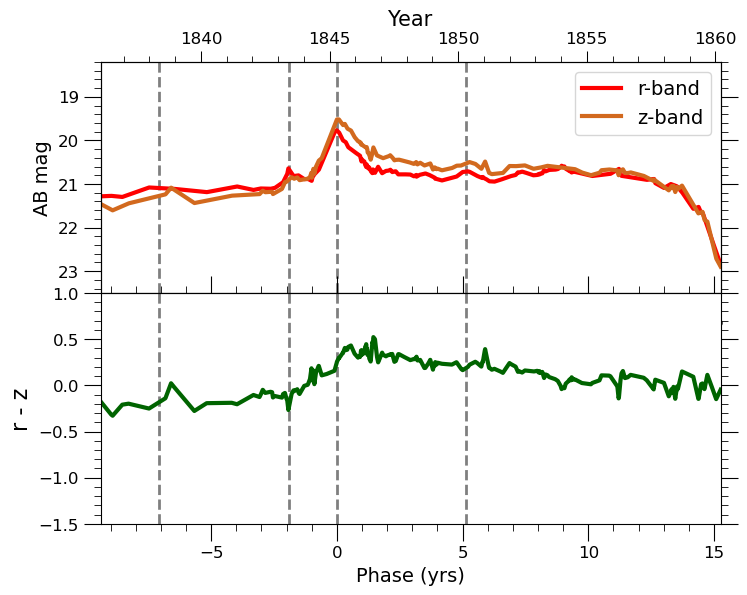

In [27]:
# r - z

y1 = r_new
y2 = z_new

fig, axs = plt.subplots(2,1,dpi = 100, figsize = [8,6], sharex=True)
axs = axs.flatten()

axs[0].errorbar((t_ran+phase_offset)/day2yr, y1, ecolor='black', color='red',label='r-band', linewidth=3)
axs[0].errorbar((t_ran+phase_offset)/day2yr, y2, ecolor='black', color='chocolate',label='z-band', linewidth=3)
axs[0].set_ylabel('AB mag', fontsize = 14)
axs[0].set_ylim(18.2, 23.5)
axs[0].invert_yaxis()
axs[0].legend(fontsize = 14)

axs[1].errorbar((t_ran+phase_offset)/day2yr, y1-y2, ecolor='black', color='darkgreen', linewidth=3)
# axs[1].set_xlabel('MJD (days)', fontsize = 14)
axs[1].set_xlabel('Phase (yrs)', fontsize = 14)
axs[1].set_ylabel('r - z', fontsize = 16)
axs[1].set_ylim(-1.5,1.)

for ax in axs:
    ax.minorticks_on()
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
    ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
    ax.ticklabel_format(axis='both', style='plain')

    ax.set_xlim((54000+phase_offset)/day2yr, (63000+phase_offset)/day2yr)
    ax.axvline((54850+phase_offset)/day2yr, color='k', ls='--', alpha=0.5, lw=2)
    ax.axvline((56740+phase_offset)/day2yr, color='k', ls='--', alpha=0.5, lw=2)
    ax.axvline((57430+phase_offset)/day2yr, color='k', ls='--', alpha=0.5, lw=2)
    ax.axvline((59300+phase_offset)/day2yr, color='k', ls='--', alpha=0.5, lw=2)

fig.subplots_adjust(wspace=0, hspace=0)

axs[0].tick_params(which='both', bottom='off', labelbottom='off')
ax_y = axs[0].twiny()
ax_y.errorbar(eta_historic.t['Year'], eta_historic.t['Flux'], fmt='--o', color='slategray', label='Historical LC')
# ax_y.set_xlim(1835.86, 1860.5)
ax_y.set_xlim(1836.1, 1860.2)
ax_y.set_xlabel('Year', fontsize = 15)
ax_y.minorticks_on()
ax_y.tick_params(axis='x', which='major', labelsize=12, width=0.75)
ax_y.tick_params(which='major', length=8)
ax_y.tick_params(which='minor', length=4)

fig.savefig('../figures/display/r-z_Color.png', bbox_inches = 'tight', dpi = 100)

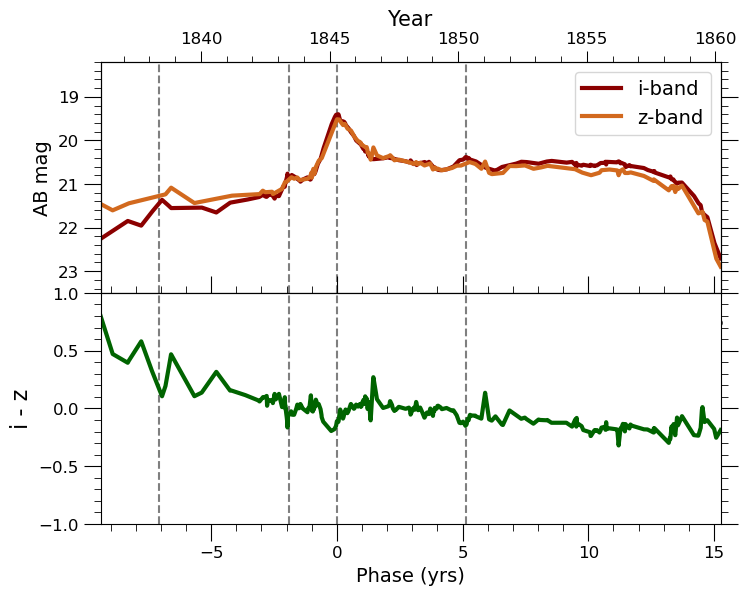

In [28]:
# i - z

y1 = i_new
y2 = z_new

fig, axs = plt.subplots(2,1,dpi = 100, figsize = [8,6], sharex=True)
axs = axs.flatten()

axs[0].errorbar((t_ran+phase_offset)/day2yr, y1, ecolor='black', color='darkred',label='i-band', linewidth=3)
axs[0].errorbar((t_ran+phase_offset)/day2yr, y2, ecolor='black', color='chocolate',label='z-band', linewidth=3)
axs[0].set_ylabel('AB mag', fontsize = 14)
axs[0].set_ylim(18.2, 23.5)
axs[0].invert_yaxis()
axs[0].legend(fontsize = 14)

axs[1].errorbar((t_ran+phase_offset)/day2yr, y1-y2, ecolor='black', color='darkgreen', linewidth=3)
# axs[1].set_xlabel('MJD (days)', fontsize = 14)
axs[1].set_xlabel('Phase (yrs)', fontsize = 14)
axs[1].set_ylabel('i - z', fontsize = 16)
axs[1].set_ylim(-1.,1.)

for ax in axs:
    ax.minorticks_on()
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.tick_params(which='major',bottom='on',top='on',left='on',right='on',length=12)
    ax.tick_params(which='minor',bottom='on',top='on',left='on',right='on',length=5)
    ax.ticklabel_format(axis='both', style='plain')

    ax.set_xlim((54000+phase_offset)/day2yr, (63000+phase_offset)/day2yr)
    ax.axvline((54850+phase_offset)/day2yr, color='k', ls='--', alpha=0.5)
    ax.axvline((56740+phase_offset)/day2yr, color='k', ls='--', alpha=0.5)
    ax.axvline((57430+phase_offset)/day2yr, color='k', ls='--', alpha=0.5)
    ax.axvline((59300+phase_offset)/day2yr, color='k', ls='--', alpha=0.5)

fig.subplots_adjust(wspace=0, hspace=0)

axs[0].tick_params(which='both', bottom='off', labelbottom='off')
ax_y = axs[0].twiny()
ax_y.errorbar(eta_historic.t['Year'], eta_historic.t['Flux'], fmt='--o', color='slategray', label='Historical LC')
# ax_y.set_xlim(1835.86, 1860.5)
ax_y.set_xlim(1836.1, 1860.2)
ax_y.set_xlabel('Year', fontsize = 15)
ax_y.minorticks_on()
ax_y.tick_params(axis='x', which='major', labelsize=12, width=0.75)
ax_y.tick_params(which='major', length=8)
ax_y.tick_params(which='minor', length=4)

fig.savefig('../figures/display/i-z_Color.png', bbox_inches = 'tight', dpi = 100)